# Raincloud Plots - Sitting - Model Comparison (M1 vs M2)

## Section 0 - Imports and configuration

In [1]:
%matplotlib inline
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms
from matplotlib.patches import Rectangle
from scipy.stats import gaussian_kde
import pandas as pd
from pathlib import Path

DATA_PATH = Path(r'C:\Projects\Scripts_results_analysis_plots\Intermodel comparison\grab7\Sitting\Mean_SD_comparison\Comparacion_Modelos_Sentado.xlsx')

# TFG display names and their CSV equivalents
MODEL_DISPLAY = {'C7': 'M1', 'NOT_C7': 'M2'}
MODEL_CSV     = {'M1': 'C7', 'M2': 'NOT_C7'}
MODEL_ORDER   = ['M1', 'M2']

MOVEMENTS_UNILATERAL = [
    'Shoulder Flex/Ext',
    'Shoulder Abd/Add',
    'Shoulder Int/Ext Rot',
    'Elbow Flex/Ext',
]
MOVEMENTS_BILATERAL = [
    'Trunk Extended Lateral Inclination',
    'Thorax Lateral Inclination',
]
MOVEMENT_LIST = MOVEMENTS_UNILATERAL + MOVEMENTS_BILATERAL

ANGLE_VARS = ['Peak_deg', 'Valley_deg', 'ROM_deg']
VAR_LABELS = {
    'Peak_deg':   'Maximum (deg)',
    'Valley_deg': 'Minimum (deg)',
    'ROM_deg':    'ROM (deg)',
}


def get_sides(movement):
    return ['Left'] if movement in MOVEMENTS_BILATERAL else ['Left', 'Right']


def get_values(df, movement, model, side, var):
    # model is display name (M1/M2); mapped to CSV value internally.
    csv_model = MODEL_CSV.get(model, model)
    col = f'{side}_{var}'
    if col not in df.columns:
        return []
    mask = (df['Movement'] == movement) & (df['Model'] == csv_model)
    return df[mask].sort_values('Rep')[col].dropna().tolist()


print('Configuration loaded.')


Configuration loaded.


## Section 1 - Data loading and validation

In [2]:
def _build_flat_df(xlsx_path):
    # Parse multi-section Sentado Excel to a flat tidy DataFrame.
    # Column index mapping (from the Excel header row):
    #  4=Left Peak, 7=Left Valley, 8=Left ROM
    # 11=Right Peak, 14=Right Valley, 15=Right ROM (unilateral only)
    raw = pd.read_excel(xlsx_path, header=None, dtype=str)
    raw = raw.fillna('').values.tolist()
    records = []
    movement = None
    bilateral = False

    for row in raw:
        cols = [str(c).strip() for c in row]
        while cols and cols[-1] == '':
            cols.pop()
        if not cols:
            continue

        is_data_val = cols[0] in ('Model', 'C7', 'NOT_C7')
        is_section  = (not is_data_val) and (len(cols) == 1 or all(c == '' for c in cols[1:]))

        if is_section:
            name = cols[0]
            bilateral = 'Bilateral' in name
            movement  = name.replace(' (Unilateral)', '').replace(' (Bilateral)', '')
            continue

        if cols[0] == 'Model' or movement is None:
            continue

        if cols[0] not in ('C7', 'NOT_C7'):
            continue

        def _f(idx):
            try:
                v = cols[idx] if idx < len(cols) else ''
                return float(v) if v else None
            except ValueError:
                return None

        rec = {
            'Movement':        movement,
            'Model':           cols[0],
            'Rep':             int(float(cols[1])),
            'Left_Peak_deg':   _f(4),
            'Left_Valley_deg': _f(7),
            'Left_ROM_deg':    _f(8),
            'Right_Peak_deg':  None if bilateral else _f(11),
            'Right_Valley_deg':None if bilateral else _f(14),
            'Right_ROM_deg':   None if bilateral else _f(15),
        }
        records.append(rec)

    return pd.DataFrame(records)


df = _build_flat_df(DATA_PATH)
print(f'Loaded {len(df)} rows x {len(df.columns)} columns from {DATA_PATH.name}')

assert set(df['Model'].unique()) == {'C7', 'NOT_C7'}, \
    f'Unexpected Model values: {set(df["Model"].unique())}'
assert set(df['Movement'].unique()) == set(MOVEMENT_LIST), \
    f'Unexpected Movement values: {set(df["Movement"].unique()) - set(MOVEMENT_LIST)}'

bil_mask = df['Movement'].isin(MOVEMENTS_BILATERAL)
assert df.loc[bil_mask, 'Right_ROM_deg'].isna().all(), \
    'Right_ROM_deg must be NaN for bilateral movements'

print('All validation checks passed.')
print()
df['Model_display'] = df['Model'].map(MODEL_DISPLAY)
counts = df.groupby(['Model_display', 'Movement']).size().rename('n')
print(counts.unstack('Model_display').to_string())


Loaded 80 rows x 9 columns from Comparacion_Modelos_Sentado.xlsx
All validation checks passed.

Model_display                       M1  M2
Movement                                  
Elbow Flex/Ext                       6   6
Shoulder Abd/Add                     6   6
Shoulder Flex/Ext                    7   7
Shoulder Int/Ext Rot                 7   7
Thorax Lateral Inclination           7   7
Trunk Extended Lateral Inclination   7   7


## Section 2 - Drawing functions

In [3]:
# ── Raincloud geometry ────────────────────────────────────────────────────
_V_AMP  = 0.25
_BW     = 0.025
_SC_OFF = 0.08
_SC_JIT = 0.025


def _draw_raincloud(ax, vals, x_c, color, color_dark, rng):
    vals = np.asarray(vals, dtype=float)
    vals = vals[~np.isnan(vals)]
    if vals.size == 0:
        return

    if vals.size >= 2:
        kde    = gaussian_kde(vals, bw_method='scott')
        spread = max(float(vals.std()) * 0.5, 0.5)
        y_grid = np.linspace(vals.min() - spread, vals.max() + spread, 300)
        dens   = kde(y_grid)
        peak_d = dens.max()
        if peak_d > 0:
            kde_x = x_c - (dens / peak_d) * _V_AMP
            ax.fill_betweenx(y_grid, kde_x, x_c,
                             color=color, alpha=0.35, zorder=2)
            ax.plot(kde_x, y_grid, color=color, alpha=0.70,
                    linewidth=0.9, zorder=3)

    q1, q2, q3 = np.percentile(vals, [25, 50, 75])
    iqr      = q3 - q1
    fence_lo = q1 - 1.5 * iqr
    fence_hi = q3 + 1.5 * iqr
    w_lo = vals[vals >= fence_lo].min() if np.any(vals >= fence_lo) else q1
    w_hi = vals[vals <= fence_hi].max() if np.any(vals <= fence_hi) else q3

    ax.plot([x_c, x_c], [w_lo, q1], color=color, lw=1.2, zorder=4)
    ax.plot([x_c, x_c], [q3, w_hi], color=color, lw=1.2, zorder=4)
    for wy in (w_lo, w_hi):
        ax.plot([x_c - _BW, x_c + _BW], [wy, wy], color=color, lw=1.2, zorder=4)
    ax.add_patch(Rectangle(
        (x_c - _BW, q1), 2 * _BW, q3 - q1,
        facecolor='white', edgecolor=color, linewidth=1.5, zorder=5,
    ))
    ax.plot([x_c - _BW, x_c + _BW], [q2, q2], color=color, lw=2.0, zorder=6)

    mean_val = float(vals.mean())
    ax.text(x_c, w_hi, f'{mean_val:.1f}',
            ha='center', va='bottom', fontsize=7.5,
            fontweight='bold', color=color_dark, zorder=7)

    outliers = vals[(vals < w_lo) | (vals > w_hi)]
    if outliers.size:
        ax.scatter(np.full(outliers.size, x_c), outliers,
                   color=color, s=18, marker='D', alpha=0.85, zorder=7)

    jitter = rng.uniform(-_SC_JIT, _SC_JIT, size=vals.size)
    ax.scatter(x_c + _SC_OFF + jitter, vals,
               color=color, s=25, alpha=0.80, zorder=3,
               edgecolors=color_dark, linewidths=0.4)


def _style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.tick_params(axis='x', length=0)
    ax.margins(y=0.22)


# ── Model colour palettes (M1 tones, M2 lighter tones) ───────────────────
MODEL_COLORS = {
    'Left': {
        'M1': ('#E74C3C', '#C0392B'),
        'M2': ('#F1948A', '#E74C3C'),
    },
    'Right': {
        'M1': ('#2ECC71', '#1E8449'),
        'M2': ('#82E0AA', '#2ECC71'),
    },
}
THORAX_COLORS = {
    'Left': {
        'M1': ('#9B59B6', '#6C3483'),
        'M2': ('#C39BD3', '#9B59B6'),
    },
}
TRUNK_COLORS = {
    'Left': {
        'M1': ('#2E86C1', '#1A5276'),
        'M2': ('#7FB3D3', '#2E86C1'),
    },
}


def _model_palette(movement):
    if 'Thorax' in movement: return THORAX_COLORS
    if 'Trunk'  in movement: return TRUNK_COLORS
    return MODEL_COLORS


print('Drawing functions defined.')


Drawing functions defined.


## Part 1 - Model comparison (M1 vs M2)

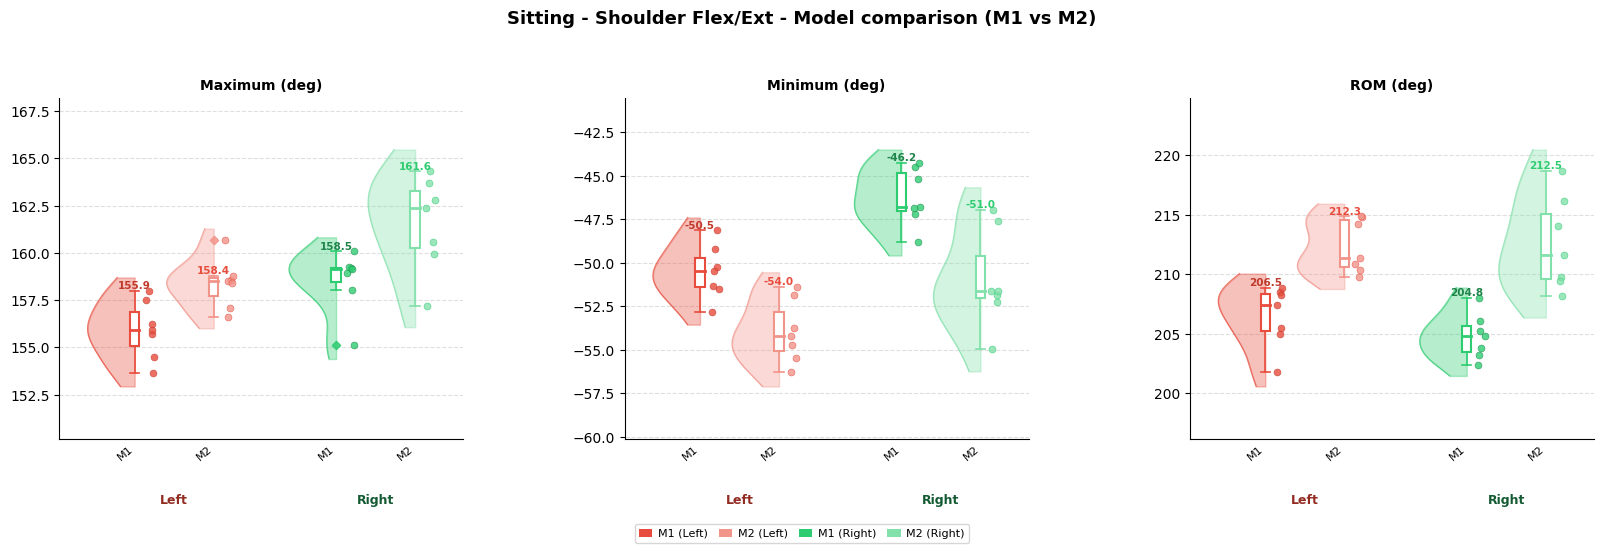

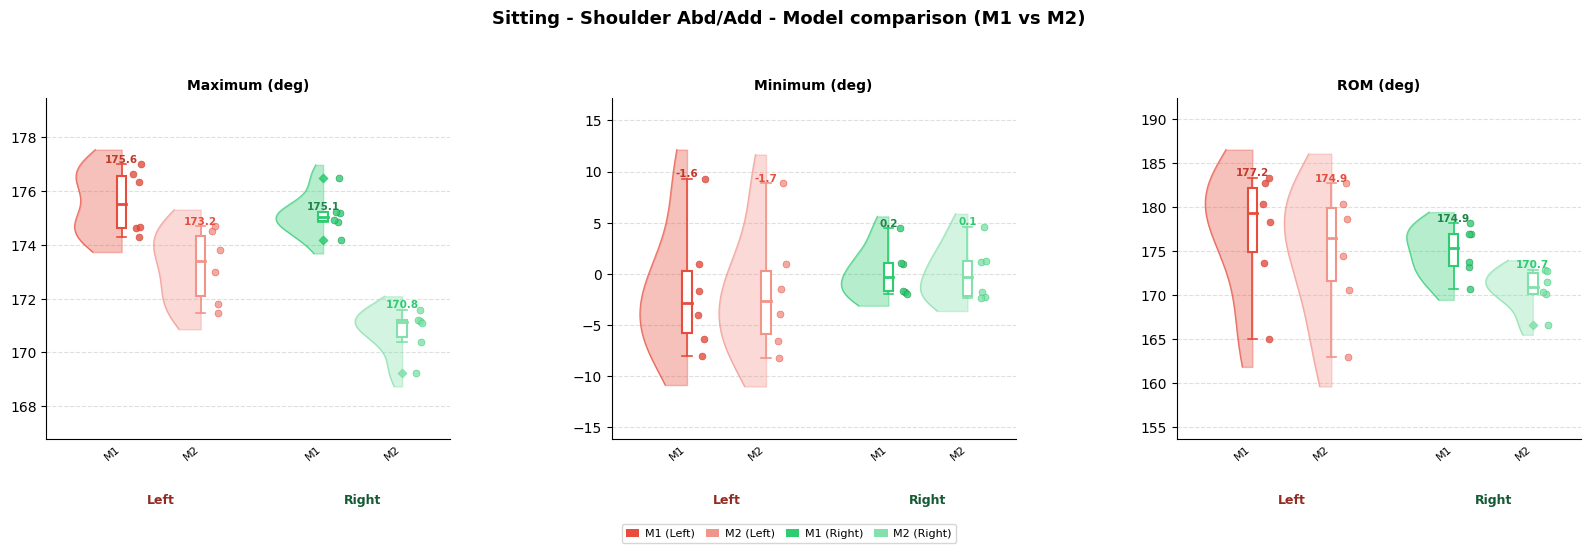

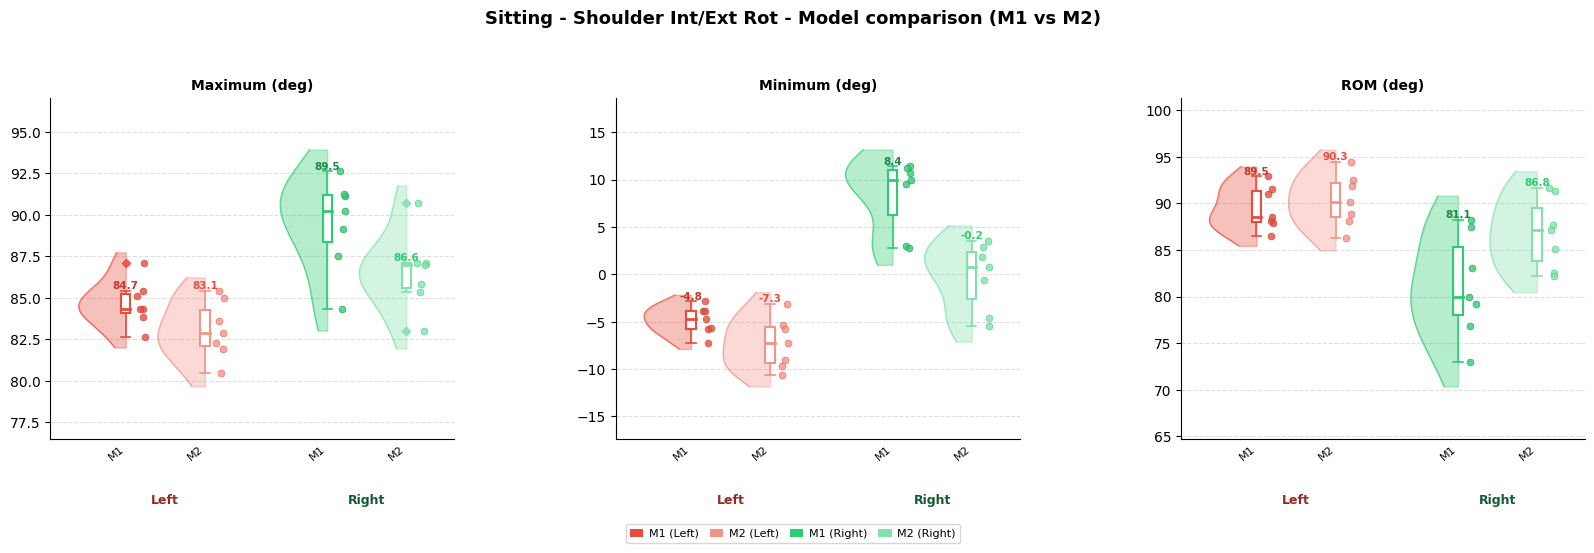

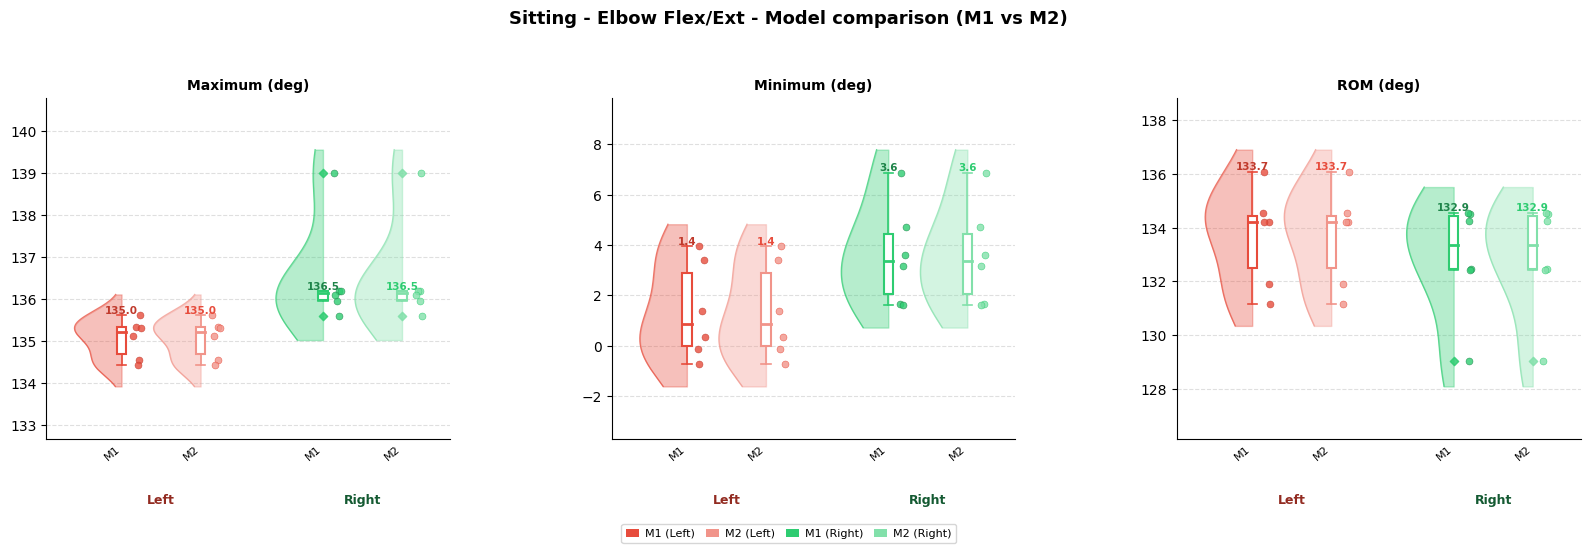

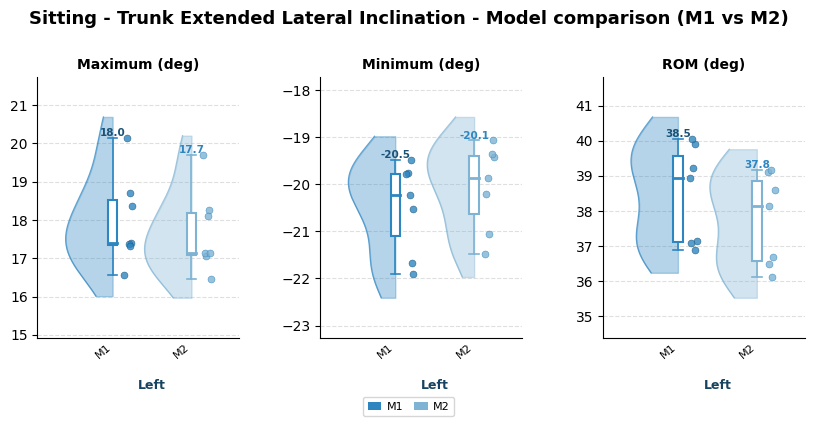

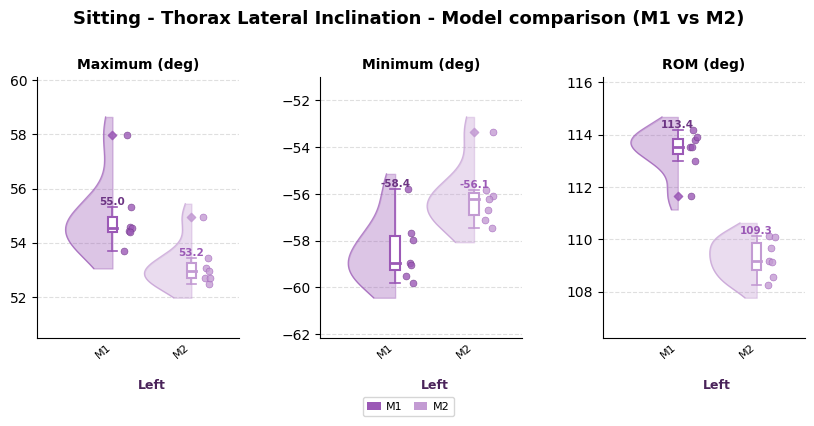

In [4]:
SPACING_P1 = 0.42
GAP_P1     = 0.65

for movement in MOVEMENT_LIST:
    sides   = get_sides(movement)
    palette = _model_palette(movement)

    n_models    = len(MODEL_ORDER)
    group_width = SPACING_P1 * (n_models - 1)

    if len(sides) == 1:
        side_centers = {'Left': 0.0}
    else:
        side_centers = {
            'Left':  -(group_width / 2 + GAP_P1 / 2),
            'Right':  (group_width / 2 + GAP_P1 / 2),
        }

    model_offsets = {
        m: (i - (n_models - 1) / 2) * SPACING_P1
        for i, m in enumerate(MODEL_ORDER)
    }

    positions = {
        (side, model): side_centers[side] + model_offsets[model]
        for side in sides for model in MODEL_ORDER
    }

    x_min = min(positions.values()) - _V_AMP - 0.15
    x_max = max(positions.values()) + _SC_OFF + _SC_JIT + 0.15

    fig_w = 5.5 * len(sides)
    fig_h = 4.2 if len(sides) == 1 else 5.5
    fig, axes = plt.subplots(1, 3, figsize=(fig_w * 1.8, fig_h))
    fig.subplots_adjust(wspace=0.40, top=0.82, bottom=0.20)
    fig.suptitle(
        f'Sitting - {movement} - Model comparison (M1 vs M2)',
        fontsize=13, fontweight='bold',
    )

    rng = np.random.default_rng(42)

    for col_idx, var in enumerate(ANGLE_VARS):
        ax = axes[col_idx]
        ax.set_title(VAR_LABELS[var], fontsize=10, fontweight='bold')

        for side in sides:
            for model in MODEL_ORDER:
                vals = get_values(df, movement, model, side, var)
                if not vals:
                    continue
                x_c = positions[(side, model)]
                color, color_dark = palette[side][model]
                _draw_raincloud(ax, vals, x_c, color, color_dark, rng)

        tick_x     = [positions[(s, m)] for s in sides for m in MODEL_ORDER]
        tick_label = [m for s in sides for m in MODEL_ORDER]
        ax.set_xticks(tick_x)
        ax.set_xticklabels(tick_label, fontsize=8, rotation=40, ha='right')
        ax.set_xlim(x_min, x_max)
        _style_ax(ax)

        side_label_colors = {'Left': '#922B21', 'Right': '#145A32'}
        if 'Thorax' in movement:
            side_label_colors = {'Left': '#4A235A'}
        elif 'Trunk' in movement:
            side_label_colors = {'Left': '#154360'}

        blended = mtransforms.blended_transform_factory(
            ax.transData, ax.transAxes
        )
        for side in sides:
            ax.text(side_centers[side], -0.16, side,
                    ha='center', va='top', fontsize=9, fontweight='bold',
                    color=side_label_colors.get(side, '#333333'),
                    transform=blended, clip_on=False)

    legend_handles = []
    for side in sides:
        for m in MODEL_ORDER:
            fill  = palette[side][m][0]
            label = m if len(sides) == 1 else f'{m} ({side})'
            legend_handles.append(mpatches.Patch(facecolor=fill, label=label))

    fig.legend(handles=legend_handles, fontsize=8,
               ncol=len(legend_handles),
               loc='lower center', bbox_to_anchor=(0.5, 0.0),
               frameon=True, handlelength=1.2,
               handletextpad=0.5, columnspacing=1.0, borderpad=0.4)

    display(fig)
    plt.close(fig)


## Part 2 - ROM Mean Difference: M2 - M1 (all movements)

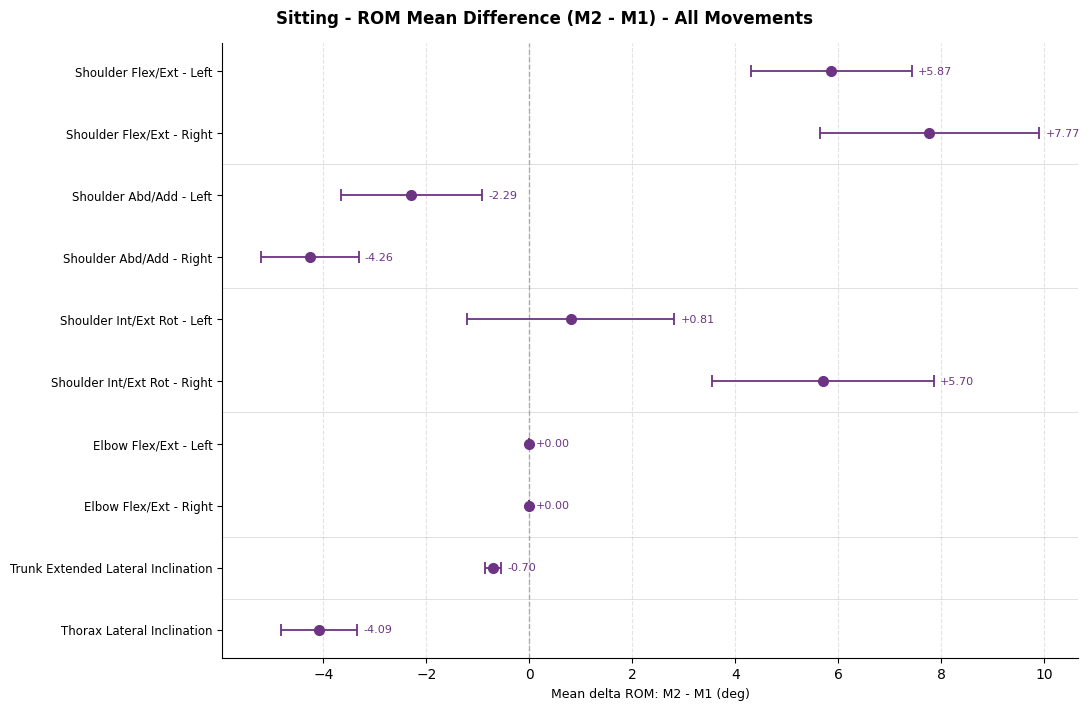

In [5]:
rows = []
for mv in MOVEMENT_LIST:
    for side in get_sides(mv):
        label = mv if mv in MOVEMENTS_BILATERAL else f'{mv} - {side}'
        rows.append((label, side, mv))

n_rows = len(rows)
fig, ax = plt.subplots(figsize=(11, max(6, n_rows * 0.72)))
fig.suptitle(
    'Sitting - ROM Mean Difference (M2 - M1) - All Movements',
    fontsize=12, fontweight='bold',
)

DIFF_COLOR = '#6C3483'

for y_idx, (label, side, mv) in enumerate(rows):
    vals_m1 = get_values(df, mv, 'M1', side, 'ROM_deg')
    vals_m2 = get_values(df, mv, 'M2', side, 'ROM_deg')
    n = min(len(vals_m1), len(vals_m2))
    if n < 2:
        continue
    diffs  = [b - a for a, b in zip(vals_m1[:n], vals_m2[:n])]
    mean_d = float(np.mean(diffs))
    sd_d   = float(np.std(diffs, ddof=1))

    ax.errorbar(
        mean_d, y_idx,
        xerr=sd_d,
        fmt='o', color=DIFF_COLOR, markersize=7,
        capsize=4, capthick=1.3, elinewidth=1.3,
        zorder=4,
    )
    x_text = mean_d + sd_d + 0.12
    ax.text(x_text, y_idx, f'{mean_d:+.2f}',
            va='center', ha='left', fontsize=8, color=DIFF_COLOR)

prev_mv = None
for y_idx, (label, side, mv) in enumerate(rows):
    if prev_mv is not None and mv != prev_mv:
        ax.axhline(y_idx - 0.5, color='gray', linewidth=0.7, alpha=0.25, zorder=1)
    prev_mv = mv

ax.axvline(0, color='gray', linewidth=1.0, linestyle='--', alpha=0.6, zorder=2)
ax.set_yticks(range(n_rows))
ax.set_yticklabels([r[0] for r in rows], fontsize=8.5)
ax.set_xlabel('Mean delta ROM: M2 - M1 (deg)', fontsize=9)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.35, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
display(fig)
plt.close(fig)
